In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from matplotlib import pyplot

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Değer Kontrolü
print("Missing values:")
print(df.isnull().sum())
print("-----------------------------")
# 3. İlk 5 Satırı Görüntüle
print(df.head())

Missing values:
time    0
0_x     0
dtype: int64
-----------------------------
   time  0_x
0  0.00  637
1  0.04  638
2  0.08  638
3  0.12  638
4  0.16  638


Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.9363546666458
Gerçek: 630, Tahmin: 630.4874908872315
Gerçek: 628, Tahmin: 629.2652330598488
Gerçek: 627, Tahmin: 627.2509530234804
Gerçek: 627, Tahmin: 626.317329088856
Gerçek: 627, Tahmin: 626.8354151118009
Gerçek: 627, Tahmin: 627.2829241164823
Gerçek: 626, Tahmin: 627.1998606834702
Gerçek: 626, Tahmin: 625.7708784204098
Gerçek: 625, Tahmin: 625.8246758742551
Gerçek: 624, Tahmin: 624.7349190376793
Gerçek: 624, Tahmin: 623.6774982199232
Gerçek: 623, Tahmin: 623.8014931660874
Gerçek: 623, Tahmin: 622.8975544839213
Gerçek: 622, Tahmin: 623.0040726228733
Gerçek: 622, Tahmin: 621.7782569739703
Gerçek: 622, Tahmin: 622.0156098999524
Gerçek: 622, Tahmin: 622.0881696779003
Gerçek: 620, Tahmin: 622.2753040730549
Gerçek: 620, Tahmin: 619.5488999845281
Gerçek: 619, Tahmin: 619.6482477073102
Gerçek: 620, Tahmin: 618.7705209793357
Gerçek: 620, Tahmin: 620.4699152564821
Gerçek: 620, Tahmin: 620.3857323340285
Gerçek: 620, Tahmin: 6

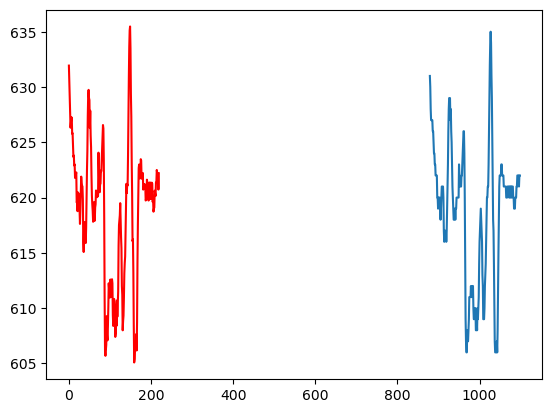

In [29]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,0,0)) # ARIMA modeli oluşturuluyor (son 5 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)


# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.7648516132203
Gerçek: 630, Tahmin: 630.4397680374394
Gerçek: 628, Tahmin: 629.1983389038548
Gerçek: 627, Tahmin: 627.0635744739743
Gerçek: 627, Tahmin: 626.3153645054035
Gerçek: 627, Tahmin: 626.8363163361525
Gerçek: 627, Tahmin: 627.1966716439059
Gerçek: 626, Tahmin: 627.2587366082133
Gerçek: 626, Tahmin: 625.830407251016
Gerçek: 625, Tahmin: 625.8628030404128
Gerçek: 624, Tahmin: 624.8861146634503
Gerçek: 624, Tahmin: 623.8059054965585
Gerçek: 623, Tahmin: 623.8471755026407
Gerçek: 623, Tahmin: 622.8628979201417
Gerçek: 622, Tahmin: 623.0046532274611
Gerçek: 622, Tahmin: 621.8364339526133
Gerçek: 622, Tahmin: 621.9871236254113
Gerçek: 622, Tahmin: 622.1467571999609
Gerçek: 620, Tahmin: 622.3313219161665
Gerçek: 620, Tahmin: 619.5913369261732
Gerçek: 619, Tahmin: 619.6586126259739
Gerçek: 620, Tahmin: 618.7668569419702
Gerçek: 620, Tahmin: 620.5036006713907
Gerçek: 620, Tahmin: 620.4547989431551
Gerçek: 620, Tahmin: 6

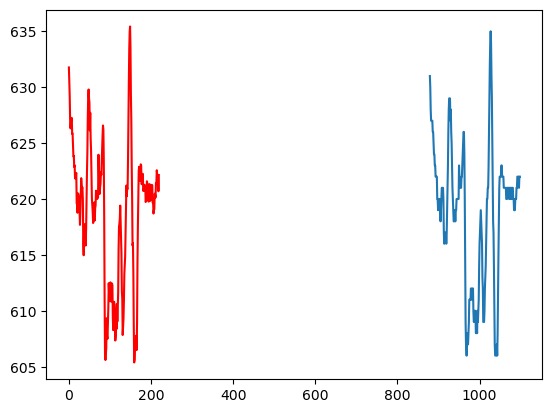

In [30]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(10,0,0)) # ARIMA modeli oluşturuluyor (son 10 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
    
# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.6507740630414
Gerçek: 630, Tahmin: 630.26494759392
Gerçek: 628, Tahmin: 629.0657264356358
Gerçek: 627, Tahmin: 627.044062099882
Gerçek: 627, Tahmin: 626.3649651054617
Gerçek: 627, Tahmin: 626.755972161788
Gerçek: 627, Tahmin: 627.1695118112843
Gerçek: 626, Tahmin: 627.1404063405577
Gerçek: 626, Tahmin: 625.5972882442925
Gerçek: 625, Tahmin: 625.7282071842329
Gerçek: 624, Tahmin: 624.8050912761546
Gerçek: 624, Tahmin: 623.7405151971191
Gerçek: 623, Tahmin: 623.8112452777514
Gerçek: 623, Tahmin: 622.9254897609958
Gerçek: 622, Tahmin: 623.1018650849951
Gerçek: 622, Tahmin: 621.8962860197739
Gerçek: 622, Tahmin: 622.153571971827
Gerçek: 622, Tahmin: 622.3550306538805
Gerçek: 620, Tahmin: 622.4726091986333
Gerçek: 620, Tahmin: 619.746537318735
Gerçek: 619, Tahmin: 619.7537369922978
Gerçek: 620, Tahmin: 618.7226953366091
Gerçek: 620, Tahmin: 620.5124000699702
Gerçek: 620, Tahmin: 620.5046846189292
Gerçek: 620, Tahmin: 620.36

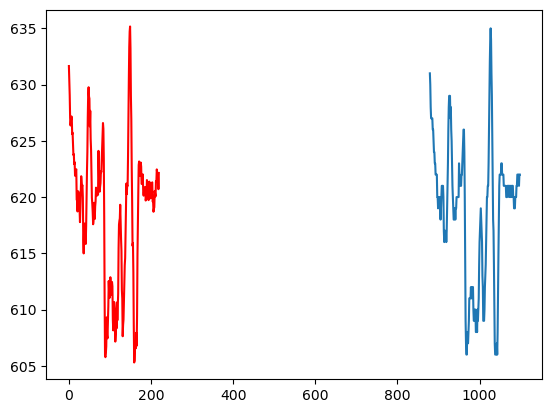

In [32]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(20,0,0)) # ARIMA modeli oluşturuluyor (son 20 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
    
# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: 

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 10.993743750052252
Gerçek: 630, Tahmin: 10.993743750052252
Gerçek: 628, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 626, Tahmin: 10.993743750052252
Gerçek: 626, Tahmin: 10.993743750052252
Gerçek: 625, Tahmin: 10.993743750052252
Gerçek: 624, Tahmin: 10.993743750052252
Gerçek: 624, Tahmin: 10.993743750052252
Gerçek: 623, Tahmin: 10.993743750052252
Gerçek: 623, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 619, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.9937437500522

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


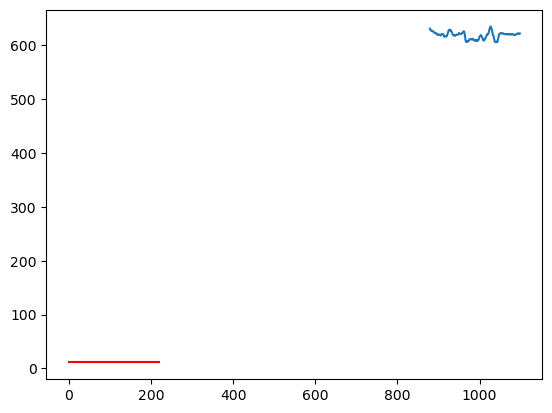

In [40]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()


# walk-forward validation
for t in range(len(test)):
    #input_data = history[-20:]
    input_data = [5,6,7,8,9,10]
    model = ARIMA(input_data, order=(5,0,0)) # ARIMA modeli oluşturuluyor (son 1 değer)
    model_fit = model.fit() # Model eğitiliyor
    output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
    yhat = output[0] # Tahmin sonucu
    predictions.append(yhat) # Tahmini kaydet
    obs = test.iloc[t] # Gerçek değer
    history.append(obs) # Modeli güncelle (bir sonraki tahmin için)

# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = root_mean_squared_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()